In [425]:
import numpy as np
a = np.array([3]*3+[1])
a
import yapss
from yapss import math
import importlib
import setup_and_solve
importlib.reload(setup_and_solve)
from setup_and_solve import *
import matplotlib.pyplot as plt
import time

In [426]:
ap = ArdupilotParameters()
optim_params = OptimizerParameters
start = StartConstraint(0, 0, 0, 0)
constraints = [Constraint(25, 50, 0)]
traj = Trajectory(start, constraints)
optim = Optimizer(traj, ap, optim_params)
dist = traj.distances()

In [427]:
st = np.array([0, 0, 0, 0])
tgt = np.array([-50, 0, 50])
a = time.perf_counter()
dist = np.linalg.norm(st[0:3] - tgt)
b = time.perf_counter()
z_dist = np.linalg.norm(st[2] - tgt[2])
print(b-a)
print(z_dist)
dist = np.sqrt((st[0] - tgt[0])**2 + (st[1] - tgt[1])**2 + (st[2] - tgt[2])**2)

problem = yapss.Problem(name = "Constraints to Trajectory",
                                nx = [4],
                                ns = 2)
begin = time.perf_counter()

def continuous(arg):
    x, y, z, phi = arg.phase[0].state
    bank, omega = arg.parameter
    xdot = ap.V_cruise*math.cos(phi)
    ydot = ap.V_cruise*math.sin(phi)
    zdot = omega
    phidot = 9.80665*math.tan(bank)/ap.V_cruise
    arg.phase[0].dynamics = [xdot, ydot, zdot, phidot]

problem.functions.continuous = continuous

problem.bounds.phase[0].initial_time.lower = problem.bounds.phase[0].initial_time.upper = 0
problem.bounds.phase[0].final_time.lower = dist/ap.V_cruise


problem.guess.phase[0].time = [0, 10]


segments, points = 9, 3
problem.mesh.phase[0].collocation_points = segments * [points]
problem.mesh.phase[0].fraction = segments * [1 / segments]
problem.ipopt_options.tol = 1e-3
finish = time.perf_counter()
print(finish-begin)

7.959996582940221e-05
50.0
0.00037050002720206976


In [428]:
def objective(arg):
    x, y, z, phi= arg.phase[0].final_state
    arg.objective = arg.phase[0].final_time + (x - tgt[0])**2 + (y - tgt[1])**2 + (z - tgt[2])**2

problem.functions.objective = objective

problem.bounds.phase[0].final_time.upper = 2*np.pi*ap.max_turn/ap.V_cruise + z_dist/ap.V_cruise
problem.bounds.phase[0].initial_state.lower = problem.bounds.phase[0].initial_state.upper = st

problem.guess.phase[0].state = [
    [st[0], tgt[0]],
    [st[1], tgt[1]],
    [st[2], tgt[2]],
    [st[3], 0]
    ]

if np.cos(st[3])*(tgt[1] - st[1]) - np.sin(st[3])*(tgt[0] - st[0]) > 0:
    bank_guess = np.pi/4
    problem.bounds.parameter.lower = [ap.roll_min_rad, -ap.max_desc]
    problem.bounds.parameter.upper = [ap.roll_limit_rad, ap.max_climb]
else:
    bank_guess = -np.pi/4
    problem.bounds.parameter.lower = [-ap.roll_limit_rad, -ap.max_desc]
    problem.bounds.parameter.upper = [-ap.roll_min_rad, ap.max_climb]
problem.guess.parameter = [bank_guess, 0]

In [429]:
begin = time.perf_counter()
sol = problem.solve()
finish = time.perf_counter()
print(finish-begin)
x, y, z, phi = sol.phase[0].state

0.11768109997501597


60.11726274274658
-12.738336177260019
0.8317078587810138


array([   0.        ,   72.06405995,  136.11507126,  184.75619127,
        212.85364015,  216.85345291,  196.74059053,  154.35428638,
         94.80480261,   24.52225533,  -48.48700516, -116.00694348,
       -170.62767404, -205.93126444, -218.33665509, -206.02366526,
       -170.80220131, -116.24383859,  -48.75992693])

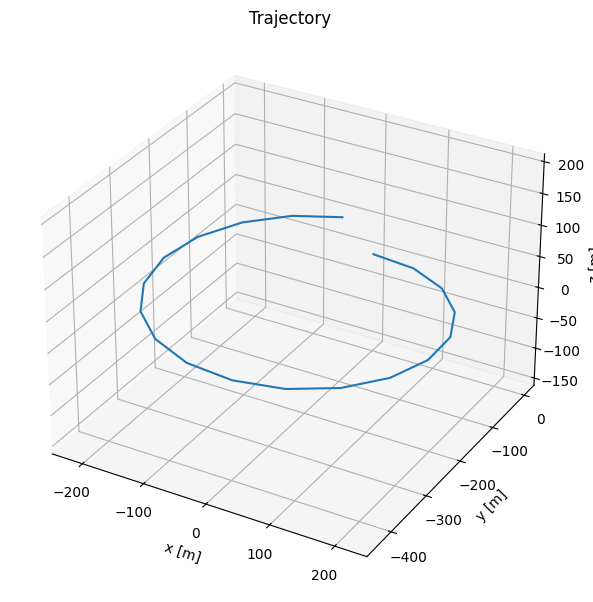

In [430]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# Go phase by phase so that each phase gets its own color.
ax1.plot(x, y, z)
ax1.set_aspect('equal', adjustable='datalim')
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_zlabel("z [m]")
ax1.set_title("Trajectory")
ax1.grid(True)
print(sol.phase[0].final_time)
print(np.rad2deg(sol.parameter[0]))
print(sol.parameter[1])
x

In [431]:
ap = ArdupilotParameters()
optim_params = OptimizerParameters()
start = StartConstraint(0, 0, 0, 0)
constraints = [Constraint(-50, 0, 50)]
traj = Trajectory(start, constraints)
optim = Optimizer(traj, ap, optim_params)

In [432]:
optim.presolve()

In [433]:
xt, yt, zt, phit = optim.initial["constr0_state"]
a, b, c = optim.initial["constr0_params"]

-12.738336177260019 22.0 0.8317078587810138


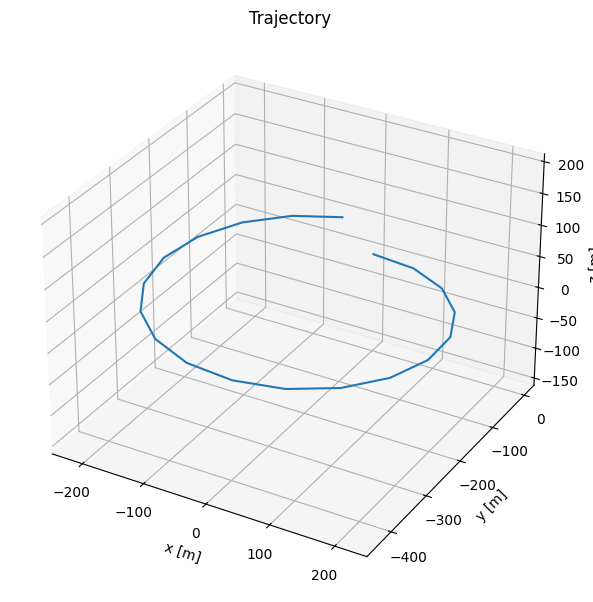

In [434]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# Go phase by phase so that each phase gets its own color.
ax1.plot(xt, yt, zt)
ax1.set_aspect('equal', adjustable='datalim')
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_zlabel("z [m]")
ax1.set_title("Trajectory")
ax1.grid(True)
print(np.rad2deg(a), b, c)

[ 0.          3.33984793  6.67969586 10.01954379 13.35939172 16.69923965
 20.03908758]
[[   0.           72.06405995  136.11507126  184.75619127  212.85364015
   216.85345291  196.74059053]
 [   0.          -12.35919279  -47.6217272  -102.21128506 -169.71322392
  -242.71993513 -313.01539124]
 [   0.            2.77777778    5.55555556    8.33333333   11.11111111
    13.88888889   16.66666667]
 [   0.           -0.33655342   -0.67310684   -1.00966026   -1.34621368
    -1.6827671    -2.01932052]]
[-0.22232591 22.          0.83170786  0.          0.          0.
  0.          0.          0.        ]
[20.03908758 23.37893551 26.71878344 30.05863137 33.3984793  36.73832723
 40.07817516]
[[ 196.74059053  154.35428638   94.80480261   24.52225533  -48.48700516
  -116.00694348 -170.62767404]
 [-313.01539124 -372.5920612  -415.01655137 -435.17447616 -431.22146897
  -403.16730149 -354.56118895]
 [  16.66666667   19.44444444   22.22222222   25.           27.77777778
    30.55555555   33.33333333]
 

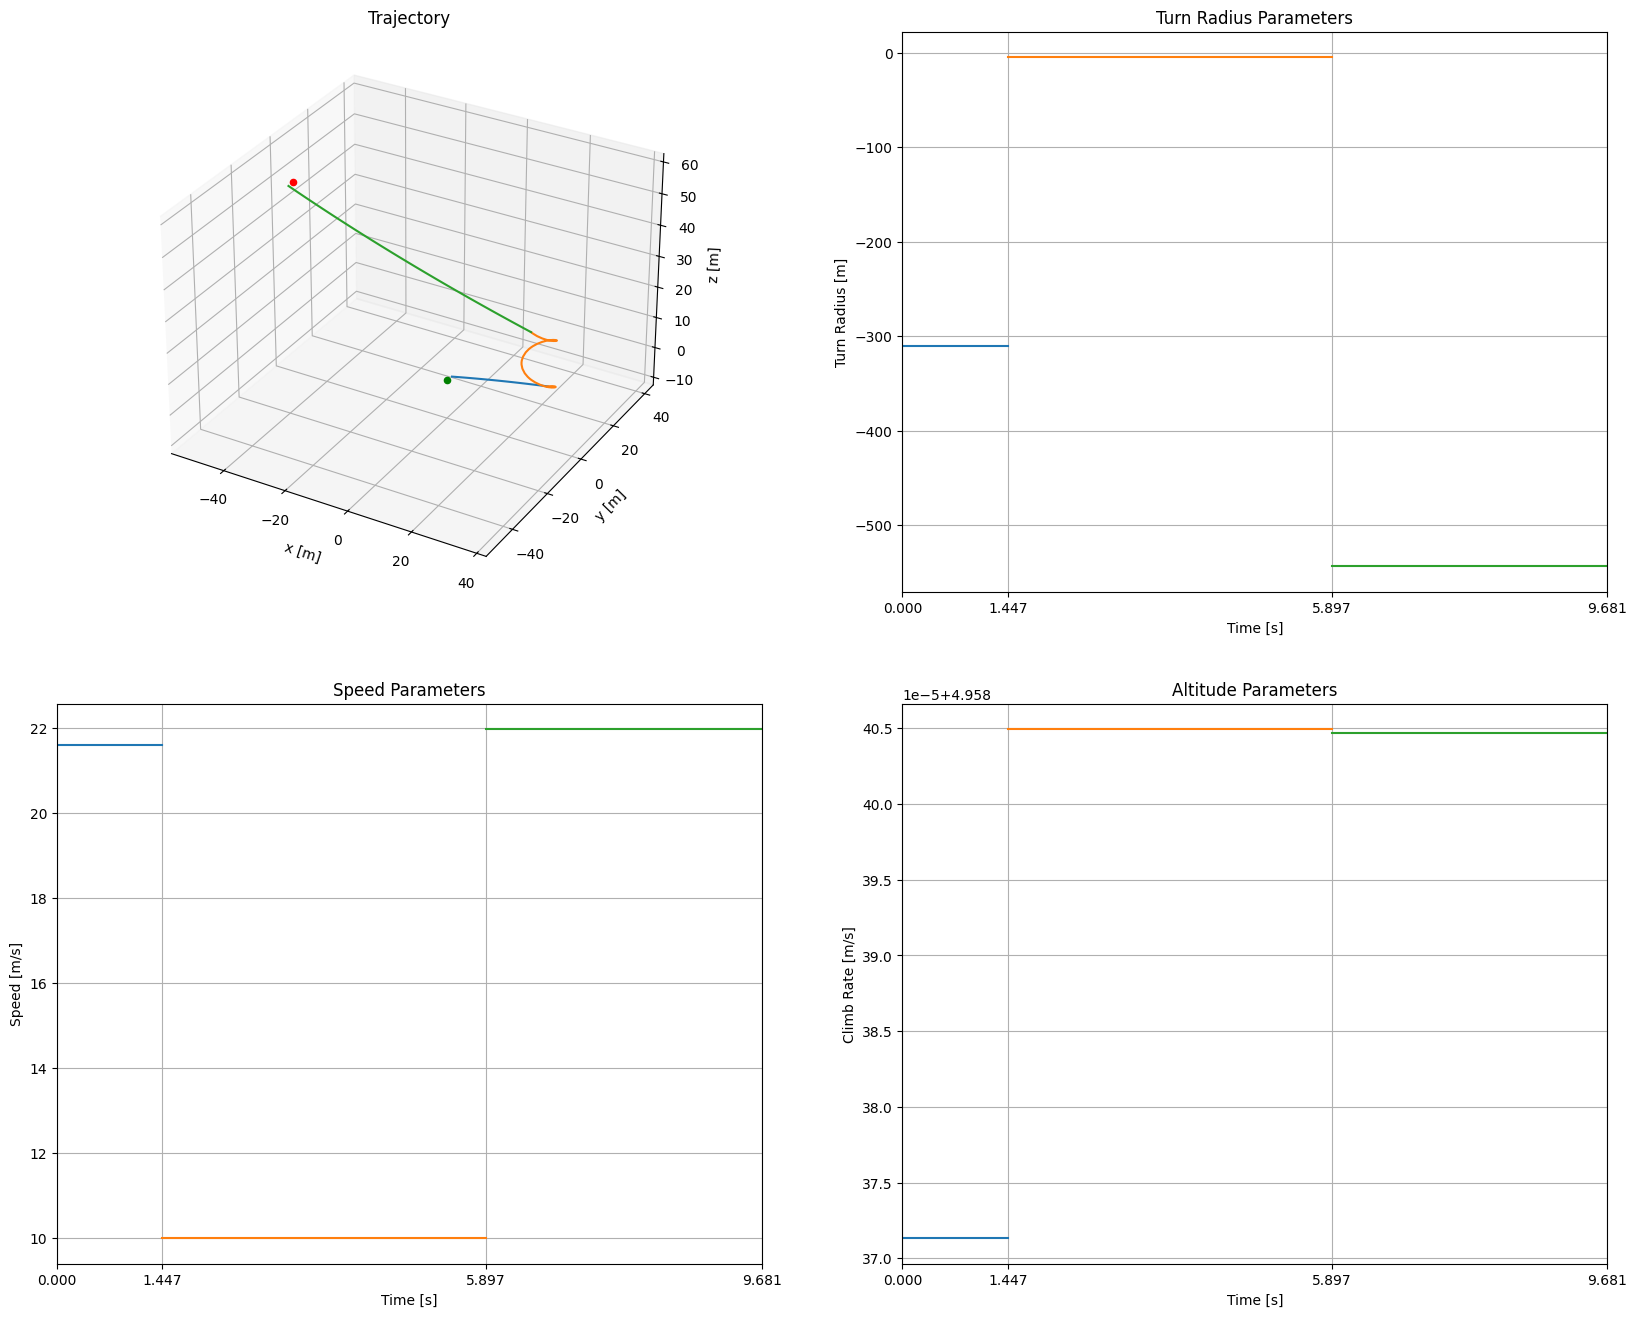

In [435]:
optim.plot()